In [1]:
import pandas as pd

df = pd.read_csv("day.csv")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [2]:
df['good_conditions'] = (
    (df['temp'] > 0.4) &
    (df['hum'] < 0.7) &
    (df['weathersit'] == 1)
).astype(int)

In [3]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,good_conditions
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,0
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,0
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,0
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,0
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,0


In [4]:
df['dteday'] = pd.to_datetime(df['dteday'])

df['day'] = df['dteday'].dt.day
df['month'] = df['dteday'].dt.month
df['year'] = df['dteday'].dt.year
df['day_of_week'] = df['dteday'].dt.weekday
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [5]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,...,windspeed,casual,registered,cnt,good_conditions,day,month,year,day_of_week,is_weekend
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,...,0.160446,331,654,985,0,1,1,2011,5,1
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,...,0.248539,131,670,801,0,2,1,2011,6,1
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,...,0.248309,120,1229,1349,0,3,1,2011,0,0
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,...,0.160296,108,1454,1562,0,4,1,2011,1,0
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,...,0.186900,82,1518,1600,0,5,1,2011,2,0


In [7]:
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)


In [8]:
df['is_month_start'] = pd.to_datetime(df['dteday']).dt.is_month_start.astype(int)
df['is_month_end'] = pd.to_datetime(df['dteday']).dt.is_month_end.astype(int)


In [9]:
df['temp_diff'] = df['atemp'] - df['temp']


In [10]:
df['bad_weather'] = df['weathersit'].isin([3, 4]).astype(int)


In [11]:
df['high_humidity'] = (df['hum'] > 0.7).astype(int)


In [12]:
df['holiday_weekend'] = ((df['holiday'] == 1) & (df['is_weekend'] == 1)).astype(int)


In [13]:
df['non_working_day'] = (df['workingday'] == 0).astype(int)


In [14]:
df['cnt_lag_1'] = df['cnt'].shift(1)


In [15]:
df['cnt_7day_avg'] = df['cnt'].rolling(7).mean()


In [16]:
df['weather_score'] = (
    (1 - df['hum']) +
    df['temp'] -
    df['windspeed']
)


In [17]:
df = pd.get_dummies(df, columns=['season', 'weathersit', 'mnth'], drop_first=True)


In [18]:
df['casual_ratio'] = df['casual'] / (df['cnt'] + 1)


In [19]:
df.head()


,instant,dteday,yr,holiday,weekday,workingday,temp,atemp,hum,windspeed,...,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,mnth_12,casual_ratio
0,1,2011-01-01,0,0,6,0,0.344167,0.363625,0.805833,0.160446,...,False,False,False,False,False,False,False,False,False,0.335700
1,2,2011-01-02,0,0,0,0,0.363478,0.353739,0.696087,0.248539,...,False,False,False,False,False,False,False,False,False,0.163342
2,3,2011-01-03,0,0,1,1,0.196364,0.189405,0.437273,0.248309,...,False,False,False,False,False,False,False,False,False,0.088889
3,4,2011-01-04,0,0,2,1,0.200000,0.212122,0.590435,0.160296,...,False,False,False,False,False,False,False,False,False,0.069098
4,5,2011-01-05,0,0,3,1,0.226957,0.229270,0.436957,0.186900,...,False,False,False,False,False,False,False,False,False,0.051218


In [20]:
df.columns

Index(['instant', 'dteday', 'yr', 'holiday', 'weekday', 'workingday', 'temp',
       'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt',
       'good_conditions', 'day', 'month', 'year', 'day_of_week', 'is_weekend',
       'is_month_start', 'is_month_end', 'temp_diff', 'bad_weather',
       'high_humidity', 'holiday_weekend', 'non_working_day', 'cnt_lag_1',
       'cnt_7day_avg', 'weather_score', 'season_2', 'season_3', 'season_4',
       'weathersit_2', 'weathersit_3', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5',
       'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12',
       'casual_ratio'],
      dtype='object')

In [21]:
drop_cols = ['instant', 'dteday', 'casual', 'registered', 'cnt']

X = df.drop(columns=drop_cols)
y = df['cnt']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [23]:
# Data manipulation
import pandas as pd
import numpy as np

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Model evaluation
from sklearn.metrics import mean_squared_error, r2_score

# Train-test split
from sklearn.model_selection import train_test_split

In [25]:
# Check total missing values per column
X_train.isnull().sum()

yr                 0
holiday            0
weekday            0
workingday         0
temp               0
atemp              0
hum                0
windspeed          0
good_conditions    0
day                0
month              0
year               0
day_of_week        0
is_weekend         0
is_month_start     0
is_month_end       0
temp_diff          0
bad_weather        0
high_humidity      0
holiday_weekend    0
non_working_day    0
cnt_lag_1          1
cnt_7day_avg       5
weather_score      0
season_2           0
season_3           0
season_4           0
weathersit_2       0
weathersit_3       0
mnth_2             0
mnth_3             0
mnth_4             0
mnth_5             0
mnth_6             0
mnth_7             0
mnth_8             0
mnth_9             0
mnth_10            0
mnth_11            0
mnth_12            0
casual_ratio       0
dtype: int64

In [26]:
# Fill NaNs in training set
X_train['cnt_lag_1'] = X_train['cnt_lag_1'].fillna(X_train['cnt_lag_1'].mean())
X_train['cnt_7day_avg'] = X_train['cnt_7day_avg'].fillna(X_train['cnt_7day_avg'].mean())

# Fill NaNs in test set using training mean (important!)
X_test['cnt_lag_1'] = X_test['cnt_lag_1'].fillna(X_train['cnt_lag_1'].mean())
X_test['cnt_7day_avg'] = X_test['cnt_7day_avg'].fillna(X_train['cnt_7day_avg'].mean())

In [27]:
X_train[['cnt_lag_1','cnt_7day_avg']].isnull().sum()
X_test[['cnt_lag_1','cnt_7day_avg']].isnull().sum()

cnt_lag_1       0
cnt_7day_avg    0
dtype: int64

In [28]:
# Linear Regressio
lr = LinearRegression()
lr.fit(X_train, y_train)
print("Linear Regression trained ✅")

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
print("Decision Tree trained ✅")

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest trained ✅")

# Gradient Boosting
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
print("Gradient Boosting trained ✅")

Linear Regression trained ✅
Decision Tree trained ✅
Random Forest trained ✅
Gradient Boosting trained ✅


In [29]:
models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="R2 Score", ascending=False)

,Model,RMSE,R2 Score
3,Gradient Boosting,676.787286,0.885772
2,Random Forest,706.670905,0.875462
0,Linear Regression,759.776472,0.856041
1,Decision Tree,794.625904,0.842531


In [30]:
import pandas as pd

# Get feature importance
best_model = gb  # Gradient Boosting
importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Top 10 features
print(importances.head(10))

cnt_7day_avg       0.645997
cnt_lag_1          0.143395
weather_score      0.087006
atemp              0.036129
hum                0.011589
temp               0.009445
good_conditions    0.009412
weekday            0.007284
casual_ratio       0.006793
windspeed          0.006480
dtype: float64


In [31]:
# Use the best model (Gradient Boosting) to predict on X_test
y_pred = gb.predict(X_test)


In [32]:
# Compare actual vs predicted
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison.head(10))


     Actual    Predicted
703    6606  5651.669500
33     1550  1698.130110
300    3747  3500.910575
456    6041  5228.316114
633    7538  7832.228655
557    7264  6648.755137
39     1605  1599.424412
356    2209  3088.785455
559    7499  6868.331109
514    5743  6603.101853


In [33]:
# Predict with Decision Tree
y_pred_dt = dt.predict(X_test)

# Compare actual vs predicted
comparison_dt = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_dt})
print("Decision Tree - First 10 Predictions")
print(comparison_dt.head(10))


Decision Tree - First 10 Predictions
     Actual  Predicted
703    6606     6235.0
33     1550     1927.0
300    3747     5566.0
456    6041     5558.0
633    7538     7466.0
557    7264     7424.0
39     1605     1623.0
356    2209     3068.0
559    7499     7639.0
514    5743     6569.0


In [34]:
# Predict with Random Forest
y_pred_rf = rf.predict(X_test)

# Compare actual vs predicted
comparison_rf = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_rf})
print("Random Forest - First 10 Predictions")
print(comparison_rf.head(10))


Random Forest - First 10 Predictions
     Actual  Predicted
703    6606    5544.53
33     1550    1550.78
300    3747    3705.49
456    6041    5619.17
633    7538    7535.69
557    7264    6582.88
39     1605    1531.61
356    2209    3237.47
559    7499    7072.90
514    5743    6504.73


In [35]:
# Predict with Decision Tree
y_pred_dt = dt.predict(X_test)

# Compare actual vs predicted
comparison_dt = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_dt})
print("Decision Tree - First 10 Predictions")
print(comparison_dt.head(10))


Decision Tree - First 10 Predictions
     Actual  Predicted
703    6606     6235.0
33     1550     1927.0
300    3747     5566.0
456    6041     5558.0
633    7538     7466.0
557    7264     7424.0
39     1605     1623.0
356    2209     3068.0
559    7499     7639.0
514    5743     6569.0


In [40]:
print("Train columns:", X_train.columns)
print("Test columns:", X_test.columns)


Train columns: Index(['yr', 'holiday', 'weekday', 'workingday', 'temp', 'atemp', 'hum',
       'windspeed', 'good_conditions', 'day', 'month', 'year', 'day_of_week',
       'is_weekend', 'is_month_start', 'is_month_end', 'temp_diff',
       'bad_weather', 'high_humidity', 'holiday_weekend', 'non_working_day',
       'cnt_lag_1', 'cnt_7day_avg', 'weather_score', 'season_2', 'season_3',
       'season_4', 'weathersit_2', 'weathersit_3', 'mnth_2', 'mnth_3',
       'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10',
       'mnth_11', 'mnth_12', 'casual_ratio', 'day_sin', 'day_cos', 'month_sin',
       'month_cos'],
      dtype='object')
Test columns: Index(['yr', 'holiday', 'weekday', 'workingday', 'temp', 'atemp', 'hum',
       'windspeed', 'good_conditions', 'day', 'month', 'year', 'day_of_week',
       'is_weekend', 'is_month_start', 'is_month_end', 'temp_diff',
       'bad_weather', 'high_humidity', 'holiday_weekend', 'non_working_day',
       'cnt_lag_1', 'cnt_7day_

In [41]:
import numpy as np

X_test['day_sin'] = np.sin(2 * np.pi * X_test['day']/31)
X_test['day_cos'] = np.cos(2 * np.pi * X_test['day']/31)

X_test['month_sin'] = np.sin(2 * np.pi * X_test['month']/12)
X_test['month_cos'] = np.cos(2 * np.pi * X_test['month']/12)


In [42]:
X_test = X_test[X_train.columns]


In [43]:
X_test['cnt_lag_1'] = X_test['cnt_lag_1'].fillna(X_train['cnt_lag_1'].mean())
X_test['cnt_7day_avg'] = X_test['cnt_7day_avg'].fillna(X_train['cnt_7day_avg'].mean())


In [45]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)


,loss,'squared_error'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [46]:
y_pred = gb.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")


RMSE: 659.5900557917488
R² Score: 0.891503288528439


In [47]:
# Use the best model (Gradient Boosting) to predict on X_test
y_pred = gb.predict(X_test)


In [48]:
# Compare actual vs predicted
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison.head(10))


     Actual    Predicted
703    6606  5703.583834
33     1550  1676.503037
300    3747  3482.282456
456    6041  4884.481296
633    7538  7915.262364
557    7264  6779.934838
39     1605  1460.487499
356    2209  3087.372826
559    7499  7059.814175
514    5743  6573.706073


In [58]:
X_train.isna().sum().sort_values(ascending=False).head(10)

cnt_7day_avg       5
cnt_lag_1          1
weekday            0
holiday            0
temp               0
atemp              0
hum                0
workingday         0
yr                 0
good_conditions    0
dtype: int64

In [59]:
X_train.isna().sum()

yr                 0
holiday            0
weekday            0
workingday         0
temp               0
atemp              0
hum                0
windspeed          0
good_conditions    0
day                0
month              0
year               0
day_of_week        0
is_weekend         0
is_month_start     0
is_month_end       0
temp_diff          0
bad_weather        0
high_humidity      0
holiday_weekend    0
non_working_day    0
cnt_lag_1          1
cnt_7day_avg       5
weather_score      0
season_2           0
season_3           0
season_4           0
weathersit_2       0
weathersit_3       0
mnth_2             0
mnth_3             0
mnth_4             0
mnth_5             0
mnth_6             0
mnth_7             0
mnth_8             0
mnth_9             0
mnth_10            0
mnth_11            0
mnth_12            0
casual_ratio       0
dtype: int64

In [60]:
mask = X_train.notna().all(axis=1)

X_train = X_train[mask]
y_train = y_train[mask]


In [61]:
mask_test = X_test.notna().all(axis=1)

X_test = X_test[mask_test]
y_test = y_test[mask_test]

In [62]:
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

print("Models trained successfully ✅")


Models trained successfully ✅


In [63]:
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)

from sklearn.metrics import r2_score

print("Linear Regression Accuracy:", r2_score(y_test, y_pred_lr) * 100)
print("Decision Tree Accuracy:", r2_score(y_test, y_pred_dt) * 100)
print("Random Forest Accuracy:", r2_score(y_test, y_pred_rf) * 100)
print("Gradient Boosting Accuracy:", r2_score(y_test, y_pred_gb) * 100)


Linear Regression Accuracy: 85.81054121434832
Decision Tree Accuracy: 84.41593265428685
Random Forest Accuracy: 87.28473130953459
Gradient Boosting Accuracy: 88.51355322646701


In [64]:
df.columns

Index(['instant', 'dteday', 'yr', 'holiday', 'weekday', 'workingday', 'temp',
       'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt',
       'good_conditions', 'day', 'month', 'year', 'day_of_week', 'is_weekend',
       'is_month_start', 'is_month_end', 'temp_diff', 'bad_weather',
       'high_humidity', 'holiday_weekend', 'non_working_day', 'cnt_lag_1',
       'cnt_7day_avg', 'weather_score', 'season_2', 'season_3', 'season_4',
       'weathersit_2', 'weathersit_3', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5',
       'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12',
       'casual_ratio'],
      dtype='object')

In [66]:
drop_cols = [
    'instant',
    'dteday',
    'yr',
    'month',
    'weekday',
    'temp',
    'casual',
    'registered',
    'cnt',
    'casual_ratio'
]

In [67]:
X = df.drop(columns=drop_cols)
y = df['cnt']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Remove NaNs from lag features
mask = X_train.notna().all(axis=1)
X_train, y_train = X_train[mask], y_train[mask]

mask_test = X_test.notna().all(axis=1)
X_test, y_test = X_test[mask_test], y_test[mask_test]


In [68]:
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

print("All models trained successfully ✅")


All models trained successfully ✅


In [69]:
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)


In [70]:
from sklearn.metrics import r2_score

print("Linear Regression Accuracy:", r2_score(y_test, y_pred_lr) * 100)
print("Decision Tree Accuracy:", r2_score(y_test, y_pred_dt) * 100)
print("Random Forest Accuracy:", r2_score(y_test, y_pred_rf) * 100)
print("Gradient Boosting Accuracy:", r2_score(y_test, y_pred_gb) * 100)


Linear Regression Accuracy: 85.96454609245046
Decision Tree Accuracy: 84.92438625033651
Random Forest Accuracy: 87.40067996086621
Gradient Boosting Accuracy: 89.06662525857621


In [73]:
gb = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

from sklearn.metrics import r2_score
print("Tuned GB Accuracy:", r2_score(y_test, y_pred_gb) * 100)

Tuned GB Accuracy: 89.33292261209104


In [74]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)


In [75]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

gb.fit(X_train, y_train_log)
y_pred_log = gb.predict(X_test)

y_pred = np.expm1(y_pred_log)


In [76]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("Gradient Boosting Accuracy (R²):", r2 * 100)


Gradient Boosting Accuracy (R²): 90.41033101019448


In [77]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Gradient Boosting RMSE:", rmse)


Gradient Boosting RMSE: 617.6482598647257


In [78]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("Gradient Boosting MAE:", mae)


Gradient Boosting MAE: 442.90857906940283


In [79]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

print(comparison)


   Actual    Predicted
0    6606  5605.472897
1    1550  1521.880348
2    3747  3690.675326
3    6041  5048.402813
4    7538  8234.130234
5    7264  6923.130700
6    1605  1500.992923
7    2209  3161.345209
8    7499  6893.171411
9    5743  6161.894999


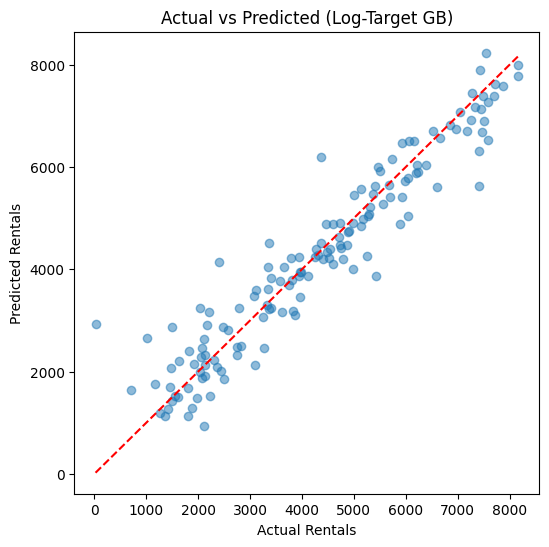

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Rentals")
plt.ylabel("Predicted Rentals")
plt.title("Actual vs Predicted (Log-Target GB)")
plt.show()


In [83]:
!pip install xgboost lightgbm catboost


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 696.5 kB/s eta 0:01:43
   ---------------------------------------- 0.5/72.0 MB 696.5 kB/s eta 0:01:43
   ---------------------------------------- 0.8/72.0 MB 786.3 kB/s eta 0:01:31
    --------------------------------------- 1.0/72.0 MB 862.3 kB/s eta 0:01:23
    --------------------------------------- 1.6/72.0 MB 1.1 MB/s eta 0:01:07
   - -------------------------------------- 1.8/72.0 MB 1.1 MB/s eta 0:01:03
   - -------------------------------------- 2.1/72.0 MB 1.1 MB/s eta 0:01:03
   - -------------------------------------- 2.1/72.0 MB 1.1 MB/s eta 0:01:03
   - -------------

In [90]:
import xgboost as xgb
from sklearn.metrics import r2_score

# Ensure data is numeric
X_train = X_train.astype(float)
X_test = X_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)

# Initialize XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
print("XGBoost R²:", r2)


XGBoost R²: 0.8913754854945046


In [92]:
import lightgbm as lgb
from sklearn.metrics import r2_score

# Ensure numeric data
X_train = X_train.astype(float)
X_test = X_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)

# Create LightGBM dataset
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_test = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

# Set parameters
params = {
    'objective': 'regression',
    'metric': 'r2',
    'learning_rate': 0.1,
    'num_leaves': 31,
    'verbose': -1
}

# Train the model (simple version, no early stopping)
lgb_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=100  # fewer rounds for quick testing
)

# Predict
y_pred_lgb = lgb_model.predict(X_test)

# Evaluate
r2_lgb = r2_score(y_test, y_pred_lgb)
print("LightGBM R²:", r2_lgb)


LightGBM R²: 0.8751742739282948


In [93]:
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score

# Ensure numeric data
X_train = X_train.astype(float)
X_test = X_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)

# Initialize CatBoost model
cat_model = CatBoostRegressor(
    iterations=200,       # fewer iterations for quick testing
    learning_rate=0.1,
    depth=6,
    verbose=0,            # silent mode
    random_seed=42
)

# Train
cat_model.fit(X_train, y_train)

# Predict
y_pred_cat = cat_model.predict(X_test)

# Evaluate
r2_cat = r2_score(y_test, y_pred_cat)
print("CatBoost R²:", r2_cat)


CatBoost R²: 0.9061618748889111


In [96]:
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, y_pred_cat))
print("CatBoost RMSE:", rmse)


CatBoost RMSE: 610.9829271626456


In [97]:
smape = 100/len(y_test) * np.sum(2 * np.abs(y_pred_cat - y_test) / (np.abs(y_test) + np.abs(y_pred_cat)))
print("CatBoost SMAPE (%):", smape)


CatBoost SMAPE (%): 13.272122598526655
